## Example 1: Understanding LangGraph workflows(Fixed path)

In [1]:
from typing import TypedDict
from langgraph.graph import END, START,StateGraph
from IPython.display import display
from langchain_core.runnables import Runnable

In [2]:
class HelloWorld(TypedDict):
    message: str

In [3]:
#Node 1
def hello(state: HelloWorld) -> HelloWorld:
    print(f'Hello Node: {state["message"]}')
    return {"message" :"Returned from Node1"}

# state gains access to the keys of HelloWorld TypedDict

In [4]:
#Node2
def bye(state: HelloWorld) -> HelloWorld:
    print(f'Bye Node: {state["message"]}')
    return {"message":"Nothing to return"}

In [5]:
# Create a StateGraph with the hello and bye nodes
graph = StateGraph(HelloWorld)
graph.add_node("hello", hello)
graph.add_node("bye", bye)
#check if graph is a runnnable
isinstance(graph, Runnable) # The grapsh is not a runnable yet.

False

In [6]:
# Add edges between the nodes
graph.add_edge(START, "hello")
graph.add_edge("hello", "bye")
graph.add_edge("bye", END)

In [7]:
new_graph = graph.compile() # Now the graph is a runnable.
isinstance(new_graph, Runnable) # The grapsh is now a runnable.

True

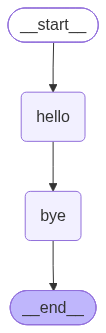

In [8]:
display(new_graph) # Display the graph in the notebook


In [9]:
output = new_graph.invoke({"message": "World!"})
print(f'Final Output: {output}')

Hello Node: World!
Bye Node: Returned from Node1
Final Output: {'message': 'Nothing to return'}


### The above example shows the fixed path. Next let us see the conditional path.

## Example 2: Understanding LangGraph workflows(conditional path)

In [10]:
# Problem:set up a graph that does the following:

# 1. Normalizes the greeting to ensure that it  is lowercase, making it easier to process.
# 2. Evaluates whether the normalized greeting contains the word 'hi'.
# 3. Branches to different greeting nodes based on this evaluation.

In [11]:
from typing import TypedDict
from langgraph.graph import END, START,StateGraph

In [12]:
class GreetingState(TypedDict):
    greeting: str

In [13]:
#Define a preprocessing node to normalize the greeting
def normalize_greeting(state):
    #Tranform the greeting to a lowercase string
    state["greeting"] = state["greeting"].lower()
    return state #Return the updated state

In [14]:
#Define a node for "Hi" greetings
def hi_greeting_node(state):
    state["greeting"] = "Hi there + state['greeting']"
    return state # Return the updated state


In [15]:
#Define a node for standard greetings
def regular_greeting_node(state):
    state["greeting"] = "Hello + state['greeting']"
    return state # Return the updated state

In [16]:
#Define the conditional the conditional function to choose the appropriate greeting.
def choose_greeting_node(state):
    #Choose the node based on whther 'hi' is in the normalized greeting
    if "hi" in state["greeting"]:
        return "hi_greeting"
    else:
        return "regular_greeting"

In [17]:
graph = StateGraph(GreetingState)
# Add nodes to the graph
graph.add_node("normalize_greeting", normalize_greeting)
graph.add_node("hi_greeting", hi_greeting_node)
graph.add_node("regular_greeting", regular_greeting_node)

In [18]:
#Add edges to the graph
graph.add_edge(START, "normalize_greeting")
graph.add_conditional_edges(
    "normalize_greeting",
    choose_greeting_node,
    ["hi_greeting", "regular_greeting"],
)
graph.add_edge("hi_greeting", END)
graph.add_edge("regular_greeting", END)


In [19]:
graph = graph.compile() # Now the graph is a runnable.

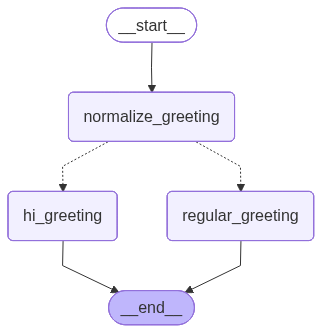

In [20]:
display(graph) # Display the graph in the notebook

In [21]:
result = graph.invoke({"greeting": "Hi there!"})
print(f'Final Output: {result}')

Final Output: {'greeting': "Hi there + state['greeting']"}


In [22]:
result1= graph.invoke({"greeting": "Hellore!"})
print(f'Final Output: {result1}')

Final Output: {'greeting': "Hello + state['greeting']"}


## Example 3:The basics of LangGraph messaging

In [23]:
# Our goal is to create an LLM that can.
#1. Understand questions from a user, such as what is the weather today?
#2 Generate intelligent responses using LLM as the intelligence provider.
#3 Triggertool nodes when necessary to fetch realtime information.

# Defining tool integration:





To demonstrate tool integration let us define a simple tool that fetches weather information for a given city,  
This tool will simulate a weather service by returning a predefined response for certain cities

In [24]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END,MessagesState

In [25]:
model = ChatOllama(model="llama3.2:3b")

In [26]:
# Node function to handle the user query and call the LLM

In [27]:
def call_llm(state:MessagesState):
    print(f"The state is in fact a dictionary: {state}")  # Debugging line to check the last message content
    stored_message = state["messages"]
    response = model.invoke(stored_message[-1].content)  # assuming the last message is the user query
    return {"messages": [response]}

In [28]:
# Define the graph

workflow = StateGraph(MessagesState)
#Add the node to call the LLM
workflow.add_node("call_llm", call_llm)
#Define the edges of the graph
workflow.add_edge(START, "call_llm")
workflow.add_edge("call_llm", END)


In [29]:
#Compile the workflow

app = workflow.compile() # Now the graph is a runnable.


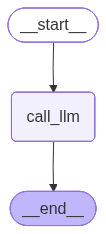

In [30]:
display(app) # Display the graph in the notebook

In [31]:
#Input message

# input_message = {"messages":[{"role":"user ", "content":"What is the weather today?"}]}  
input_message = {"messages":[("human", "What is the capital of Zimbabwe?")]}


In [32]:
#Run the workflow
for chunk in app.stream(input_message,stream_mode="values"):
    # print(chunk, end="\n\n")
    chunk["messages"][-1].pretty_print() # Pretty print the last message in the chunk

================================ Human Message =================================

What is the capital of Zimbabwe?
The state is in fact a dictionary: {'messages': [HumanMessage(content='What is the capital of Zimbabwe?', additional_kwargs={}, response_metadata={}, id='4c12456a-625d-417e-b027-267554a59739')]}
================================== Ai Message ==================================

The capital of Zimbabwe is Harare.


In [33]:
#Function to handle to continously take the input 

def interact_with_agent():
    while True:
        user_input = input("User: ")
        if user_input.lower() in ["exit", "quit"]:
            print("Exiting the interaction.")
            break
        input_message = {"messages":[("human", user_input)]}
        for chunk in app.stream(input_message, stream_mode="values"):
            chunk["messages"][-1].pretty_print()  # Pretty print the last message in the chunk
            
interact_with_agent()  # Start the interaction loop

Exiting the interaction.


In [34]:
@tool
def get_weather(location:str):
    """Fetch the current weather for a given location"""
    weather_data = {'San Francisco': 'Sunny, 25°C', 'New York': 'Cloudy, 18°C', 'London': 'Rainy, 12°C'}
    return weather_data.get(location, "Weather data not available for this location.")  


In [35]:
tool_node = ToolNode([get_weather])  # Create a ToolNode with the get_weather tool. If there were other other tools, they could be added to the list as well.

# Update the LLM to use Tools

In [36]:
model = ChatOllama(model="llama3.2:3b").bind_tools([get_weather])

In [37]:
def call_llm(state:MessagesState):
   
    stored_message = state["messages"]
    messages_with_system = [
        ("system", "Only call get_weather when the user explicitly asks about weather realted questions.")
    ] + stored_message
    #The LLM decides whether to call the tool or not based on the user query
    response = model.invoke(messages_with_system)  # assuming the last message is the user query
    if response.tool_calls:
        tool_result = tool_node.invoke({"messages": [response]})  # Pass the response to the tool node
        tool_message = tool_result["messages"][-1].content  # Assuming the tool returns a message in the same format
        #Append the tool result to the response content or handle it as needed
        response.content += f"\nTool Result: {tool_message}"
    return {"messages": [response]}

### Line-by-line notes

- `def call_llm(state:MessagesState):`
  Creates a function named `call_llm` that receives the current LangGraph state. The state is expected to follow the `MessagesState` structure.

- `print(f"The state is in fact a dictionary: {state}")`
  Prints the full state to the output so you can inspect what data is being passed into the function while debugging.

- `stored_message = state["messages"]`
  Reads the `messages` value from the state dictionary and stores it in a variable called `stored_message`.

- `#The LLM decides whether to call the tool or not based on the user query`
  This comment explains that the model will look at the user request and decide whether a tool should be used.

- `response = model.invoke(stored_message[-1].content)`
  Sends the content of the last message in the conversation to the model and stores the model's reply in `response`.

- `if response.tool_calls:`
  Checks whether the model asked to use any tool. If it did, the code inside this block will run.

- `tool_result = tool_node.invoke({"messages": [response]})`
  Runs the tool node and passes in the model response as a `messages` payload so the tool node can process the requested tool call.
  Here is what that means in simpler terms:
  - `tool_node` is the object that knows how to run your tools.
  - `.invoke(...)` means “run this tool node now.”
  - `{"messages": [response]}` is the input being sent into the tool node.
  - The tool node expects its input in message format, so the data must be under the `messages` key.
  - `response` is a single AI message object returned by the model.
  - `[response]` wraps that one message in a list, because the tool node expects a list of messages, not just one message by itself.
  - The reason the model response is passed in is that the response may contain a tool call request, not just normal text.
  - That tool call request can include structured instructions such as which tool to call and what arguments to use.
  - By passing the response into the tool node, you are giving the tool node the AI message so it can read those instructions and run the correct tool.
  In plain language, this line means: “Here is the AI's latest reply. If that reply includes an instruction to use a tool, read it and run the correct tool.”

- `tool_message = tool_result["messages"][-1].content`
  Takes the last message returned by the tool node and extracts its text content.

- `response.content += f"\nTool Result: {tool_message}"`
  Adds the tool result text onto the model's existing response text, starting on a new line.

- `return {"messages": [response]}`
  Returns the model response in a dictionary under the `messages` key so LangGraph can pass it to the next step in the workflow.

### What the whole function does

It takes the latest chat message, sends it to the model, checks whether the model wants to use a tool, passes the model's tool request to the tool node, adds the tool output if needed, and returns the final response back into the graph.

In [38]:
#Create a new workflow with the updated call_llm function that can handle tool calls
workflow_with_tools = StateGraph(MessagesState)
workflow_with_tools.add_node("call_llm", call_llm)
workflow_with_tools.add_edge(START, "call_llm")
workflow_with_tools.add_edge("call_llm", END)

app_with_tools = workflow_with_tools.compile()  # Compile the new workflow

In [ ]:
input_message = {"messages":[("human", "How is crime in London?")]}  # Example input message

for chunk in app_with_tools.stream(input_message, stream_mode="values"):
    chunk["messages"][-1].pretty_print()  # Pretty print the last message in the chunk

================================ Human Message =================================

How is crime in London?
================================== Ai Message ==================================


Tool Result: Rainy, 12°C
Tool Calls:
  get_weather (1605a195-f30d-430a-9dc7-12fc22899cd3)
 Call ID: 1605a195-f30d-430a-9dc7-12fc22899cd3
  Args:
    location: London


: 